### Trabalho Fase 1 do Curso de Pos-Graduacao FIAP IA para Devs
#### Parte 3 - Modelo KNN usando as bases preparadas

Fonte de dados escolhida: DATASUS/SISCAN  
Tipo de dados de origem nesta etapa: Parquet

Arquivos utilizados:

```text
bases/treino/x_encoded.parquet
bases/treino/y.parquet
bases/teste/x_encoded.parquet
bases/teste/y.parquet
```

---

## Objetivo da Parte 3

Treinar e avaliar um baseline KNN (`KNeighborsClassifier`) usando as bases encoded geradas na Parte 2.

Como KNN e baseado em distancia, esta etapa compara o impacto de duas escolhas para idade e duas formas de escala:

- idade com cap: `CO_IDADE_PACIENTE_CAP`;
- idade numerica sem cap: `CO_IDADE_PACIENTE_NUM`;
- padronizacao: `StandardScaler`;
- normalizacao: `MinMaxScaler`.

Em todos os cenarios, a coluna numerica de idade escolhida e as demais variaveis numericas de contexto sao escaladas. As variaveis categoricas ja codificadas em one-hot permanecem como `0/1`, sem padronizacao ou normalizacao.

A avaliacao passa a usar a base completa exportada pela Parte 2: o conjunto de treino e dividido apenas em treino/validacao estratificados, sem recorte artificial de linhas, e o conjunto de teste completo e preservado para a avaliacao final.

---

## Indice / Sumario da Parte 3

**Item 1 - Leitura e preparacao dos dados para KNN**

- Leitura das bases encoded, separacao das colunas de idade e das dummies categoricas.

**Item 2 - Base completa, validacao e metodo de execucao**

- Separacao estratificada de treino/validacao sem recorte de linhas e definicao do metodo `executar_knn`.

**Item 3 - Comparacao dos cenarios de idade e escala**

- Comparacao entre idade cap/num e padronizacao/normalizacao usando F1 e balanced accuracy.

**Item 4 - Tuning com GridSearchCV**

- Refinamento dos hiperparametros do KNN no melhor cenario de idade encontrado.

**Item 5 - Avaliacao detalhada do KNN tunado**

- Avaliacao do melhor estimador do GridSearchCV no conjunto completo de teste.

**Item 6 - Conclusao da avaliacao KNN**

- Sintese comparativa dos cenarios, efeito do tuning, limitacoes observadas e recomendacao para proximas etapas.


#### Item 1 - Leitura e preparacao dos dados para KNN

A Parte 3 usa diretamente `x_encoded.parquet`, criado na Parte 2. Como a validacao das bases ja foi realizada na Parte 2, aqui apenas lemos os arquivos necessarios e definimos quais colunas entram em cada cenario do KNN.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 120)

RANDOM_STATE = 42
TARGET_COLUMN = 'TARGET_CANCER_MAMA_PROVAVEL'
BASES_DIR = Path('bases')

# Proporcao reservada do treino original para validacao dos cenarios iniciais.
VALIDACAO_SIZE_KNN = 0.20

arquivos_entrada = {
    'x_treino_encoded': BASES_DIR / 'treino' / 'x_encoded.parquet',
    'y_treino': BASES_DIR / 'treino' / 'y.parquet',
    'x_teste_encoded': BASES_DIR / 'teste' / 'x_encoded.parquet',
    'y_teste': BASES_DIR / 'teste' / 'y.parquet',
}

X_train_encoded = pd.read_parquet(arquivos_entrada['x_treino_encoded'])
y_train = pd.read_parquet(arquivos_entrada['y_treino'])[TARGET_COLUMN]
X_test_encoded = pd.read_parquet(arquivos_entrada['x_teste_encoded'])
y_test = pd.read_parquet(arquivos_entrada['y_teste'])[TARGET_COLUMN]

colunas_idade = ['CO_IDADE_PACIENTE_NUM', 'CO_IDADE_PACIENTE_CAP']
colunas_numericas_contexto = [
    coluna for coluna in ['CO_TEMPO_MAMO_ANTERIOR_NUM']
    if coluna in X_train_encoded.columns
]
colunas_categoricas_encoded = [
    coluna for coluna in X_train_encoded.columns
    if coluna not in colunas_idade + colunas_numericas_contexto
]

resumo_entrada_knn = {
    'shape_x_treino_encoded': X_train_encoded.shape,
    'shape_x_teste_encoded': X_test_encoded.shape,
    'colunas_idade_comparadas': colunas_idade,
    'qtd_colunas_numericas_contexto': len(colunas_numericas_contexto),
    'colunas_numericas_contexto': colunas_numericas_contexto,
    'qtd_colunas_categoricas_encoded': len(colunas_categoricas_encoded),
}
resumo_entrada_knn


{'shape_x_treino_encoded': (213978, 25),
 'shape_x_teste_encoded': (53495, 25),
 'colunas_idade_comparadas': ['CO_IDADE_PACIENTE_NUM',
  'CO_IDADE_PACIENTE_CAP'],
 'qtd_colunas_numericas_contexto': 1,
 'colunas_numericas_contexto': ['CO_TEMPO_MAMO_ANTERIOR_NUM'],
 'qtd_colunas_categoricas_encoded': 22}

#### Item 2 - Base completa, validacao e metodo de execucao

Nesta etapa nao ha mais recorte artificial para reduzir a base. O conjunto de treino gerado na Parte 2 e dividido em treino/validacao de forma estratificada, preservando todos os registros de treino. O conjunto de teste tambem e mantido completo.

Tambem definimos o metodo `executar_knn`, responsavel por selecionar as features do cenario, montar ou receber o modelo KNN, executar treino/predicao e devolver as metricas. Os itens seguintes chamam esse metodo para evitar duplicacao de logica entre as variacoes de idade, escala e hiperparametros.


In [2]:
X_train_base_knn, X_valid_base_knn, y_train_knn, y_valid_knn = train_test_split(
    X_train_encoded,
    y_train,
    test_size=VALIDACAO_SIZE_KNN,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

X_train_base_knn = X_train_base_knn.reset_index(drop=True)
X_valid_base_knn = X_valid_base_knn.reset_index(drop=True)
y_train_knn = y_train_knn.reset_index(drop=True)
y_valid_knn = y_valid_knn.reset_index(drop=True)

X_test_base_knn = X_test_encoded.reset_index(drop=True).copy()
y_test_knn = y_test.reset_index(drop=True).copy()


def selecionar_features_cenario(df, coluna_idade):
    colunas_modelo = [coluna_idade] + colunas_numericas_contexto + colunas_categoricas_encoded
    df_modelo = df[colunas_modelo].copy()
    for coluna in [coluna_idade] + colunas_numericas_contexto:
        df_modelo[coluna] = pd.to_numeric(df_modelo[coluna], errors='coerce')
    return df_modelo


def criar_pipeline_knn(coluna_idade, scaler, n_neighbors, weights):
    preprocessamento = ColumnTransformer(
        transformers=[
            ('numericas', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', scaler),
            ]), [coluna_idade] + colunas_numericas_contexto),
            ('categoricas', 'passthrough', colunas_categoricas_encoded),
        ],
        remainder='drop',
    )

    return Pipeline([
        ('preprocessamento', preprocessamento),
        ('knn', KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            metric='minkowski',
            n_jobs=-1,
        )),
    ])


def calcular_metricas_knn(y_real, y_pred, y_score=None):
    metricas = {
        'accuracy': round(accuracy_score(y_real, y_pred), 4),
        'balanced_accuracy': round(balanced_accuracy_score(y_real, y_pred), 4),
        'precision': round(precision_score(y_real, y_pred, zero_division=0), 4),
        'recall': round(recall_score(y_real, y_pred, zero_division=0), 4),
        'f1': round(f1_score(y_real, y_pred, zero_division=0), 4),
    }
    if y_score is not None:
        metricas['roc_auc'] = round(roc_auc_score(y_real, y_score), 4)
    return metricas


def executar_knn(
    X_treino,
    y_treino,
    X_avaliacao,
    y_avaliacao,
    coluna_idade,
    scaler=None,
    n_neighbors=None,
    weights=None,
    modelo=None,
    rotulo='KNN',
    linhas_treino_usadas=None,
):
    X_avaliacao_modelo = selecionar_features_cenario(X_avaliacao, coluna_idade)

    if modelo is None:
        if scaler is None or n_neighbors is None or weights is None:
            raise ValueError('Informe scaler, n_neighbors e weights quando modelo nao for fornecido.')
        X_treino_modelo = selecionar_features_cenario(X_treino, coluna_idade)
        modelo = criar_pipeline_knn(
            coluna_idade=coluna_idade,
            scaler=scaler,
            n_neighbors=n_neighbors,
            weights=weights,
        )
        modelo.fit(X_treino_modelo, y_treino)
        linhas_treino_usadas = len(X_treino_modelo)
    elif linhas_treino_usadas is None:
        linhas_treino_usadas = pd.NA

    y_pred = modelo.predict(X_avaliacao_modelo)
    y_score = None
    if hasattr(modelo, 'predict_proba'):
        y_score = modelo.predict_proba(X_avaliacao_modelo)[:, 1]

    return {
        'rotulo': rotulo,
        'modelo': modelo,
        'coluna_idade': coluna_idade,
        'linhas_treino_usadas': linhas_treino_usadas,
        'linhas_avaliadas': len(X_avaliacao_modelo),
        'metricas': calcular_metricas_knn(y_avaliacao, y_pred, y_score),
        'y_pred': y_pred,
        'y_score': y_score,
        'X_avaliacao_modelo': X_avaliacao_modelo,
    }


bases_knn = pd.DataFrame([
    {'base': 'treino_knn', 'linhas': len(X_train_base_knn), 'classe_positiva': int(y_train_knn.sum()), 'percentual_positivo': round(y_train_knn.mean() * 100, 2)},
    {'base': 'validacao_knn', 'linhas': len(X_valid_base_knn), 'classe_positiva': int(y_valid_knn.sum()), 'percentual_positivo': round(y_valid_knn.mean() * 100, 2)},
    {'base': 'teste_knn', 'linhas': len(X_test_base_knn), 'classe_positiva': int(y_test_knn.sum()), 'percentual_positivo': round(y_test_knn.mean() * 100, 2)},
])
bases_knn


,base,linhas,classe_positiva,percentual_positivo
0,treino_knn,171182,7261,4.24
1,validacao_knn,42796,1815,4.24
2,teste_knn,53495,2269,4.24


#### Item 3 - Comparacao dos cenarios de idade e escala

Cada cenario usa uma unica coluna de idade (`NUM` ou `CAP`) e mantem as demais dummies categoricas como `0/1`. A coluna de idade escolhida e as variaveis numericas de contexto passam por imputacao e escala; as dummies entram sem escala.


In [3]:
cenarios_escala = [
    {'coluna_idade': 'CO_IDADE_PACIENTE_CAP', 'idade': 'cap', 'escala': 'padronizacao', 'scaler': StandardScaler()},
    {'coluna_idade': 'CO_IDADE_PACIENTE_CAP', 'idade': 'cap', 'escala': 'normalizacao', 'scaler': MinMaxScaler()},
    {'coluna_idade': 'CO_IDADE_PACIENTE_NUM', 'idade': 'num', 'escala': 'padronizacao', 'scaler': StandardScaler()},
    {'coluna_idade': 'CO_IDADE_PACIENTE_NUM', 'idade': 'num', 'escala': 'normalizacao', 'scaler': MinMaxScaler()},
]

parametros_knn = [
    {'n_neighbors': 3, 'weights': 'uniform'},
    {'n_neighbors': 5, 'weights': 'uniform'},
    {'n_neighbors': 11, 'weights': 'uniform'},
    {'n_neighbors': 5, 'weights': 'distance'},
    {'n_neighbors': 11, 'weights': 'distance'},
]

resultados_busca = []
modelos_avaliados = {}

for cenario in cenarios_escala:
    for params in parametros_knn:
        chave = f"idade={cenario['idade']}, escala={cenario['escala']}, k={params['n_neighbors']}, weights={params['weights']}"
        execucao = executar_knn(
            X_treino=X_train_base_knn,
            y_treino=y_train_knn,
            X_avaliacao=X_valid_base_knn,
            y_avaliacao=y_valid_knn,
            coluna_idade=cenario['coluna_idade'],
            scaler=cenario['scaler'],
            n_neighbors=params['n_neighbors'],
            weights=params['weights'],
            rotulo=chave,
        )
        modelos_avaliados[chave] = execucao
        resultados_busca.append({
            'modelo': chave,
            'idade': cenario['idade'],
            'coluna_idade': cenario['coluna_idade'],
            'escala': cenario['escala'],
            'n_neighbors': params['n_neighbors'],
            'weights': params['weights'],
            'linhas_treino_usadas': execucao['linhas_treino_usadas'],
            'linhas_validacao_avaliadas': execucao['linhas_avaliadas'],
            **execucao['metricas'],
        })

resultados_busca_knn = pd.DataFrame(resultados_busca).sort_values(
    ['f1', 'balanced_accuracy'],
    ascending=False,
).reset_index(drop=True)

melhor_modelo_nome = resultados_busca_knn.loc[0, 'modelo']
melhor_modelo_info = modelos_avaliados[melhor_modelo_nome]
melhor_modelo_knn = melhor_modelo_info['modelo']

resultados_busca_knn


,modelo,idade,coluna_idade,escala,n_neighbors,weights,linhas_treino_usadas,linhas_validacao_avaliadas,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,"idade=cap, escala=padronizacao, k=5, weights=d...",cap,CO_IDADE_PACIENTE_CAP,padronizacao,5,distance,171182,42796,0.9561,0.5184,0.3476,0.0402,0.0721,0.5600
1,"idade=num, escala=padronizacao, k=3, weights=u...",num,CO_IDADE_PACIENTE_NUM,padronizacao,3,uniform,171182,42796,0.9524,0.5181,0.2090,0.0435,0.0720,0.5534
2,"idade=cap, escala=normalizacao, k=3, weights=u...",cap,CO_IDADE_PACIENTE_CAP,normalizacao,3,uniform,171182,42796,0.9529,0.5181,0.2179,0.0430,0.0718,0.5530
3,"idade=cap, escala=normalizacao, k=5, weights=d...",cap,CO_IDADE_PACIENTE_CAP,normalizacao,5,distance,171182,42796,0.9560,0.5182,0.3429,0.0397,0.0711,0.5589
4,"idade=num, escala=normalizacao, k=3, weights=u...",num,CO_IDADE_PACIENTE_NUM,normalizacao,3,uniform,171182,42796,0.9525,0.5176,0.2081,0.0424,0.0705,0.5538
5,"idade=num, escala=padronizacao, k=5, weights=d...",num,CO_IDADE_PACIENTE_NUM,padronizacao,5,distance,171182,42796,0.9557,0.5177,0.3170,0.0391,0.0696,0.5601
6,"idade=cap, escala=padronizacao, k=3, weights=u...",cap,CO_IDADE_PACIENTE_CAP,padronizacao,3,uniform,171182,42796,0.9528,0.5172,0.2113,0.0413,0.0691,0.5540
7,"idade=num, escala=normalizacao, k=5, weights=d...",num,CO_IDADE_PACIENTE_NUM,normalizacao,5,distance,171182,42796,0.9556,0.5171,0.3067,0.0380,0.0676,0.5591
8,"idade=cap, escala=normalizacao, k=11, weights=...",cap,CO_IDADE_PACIENTE_CAP,normalizacao,11,distance,171182,42796,0.9565,0.5155,0.3653,0.0336,0.0616,0.5677
9,"idade=cap, escala=padronizacao, k=11, weights=...",cap,CO_IDADE_PACIENTE_CAP,padronizacao,11,distance,171182,42796,0.9565,0.5144,0.3519,0.0314,0.0577,0.5682


In [4]:
comparacao_cenarios_knn = (
    resultados_busca_knn
    .sort_values(['f1', 'balanced_accuracy'], ascending=False)
    .groupby(['idade', 'escala'], as_index=False)
    .first()
    .sort_values(['f1', 'balanced_accuracy'], ascending=False)
    .reset_index(drop=True)
)
comparacao_cenarios_knn


,idade,escala,modelo,coluna_idade,n_neighbors,weights,linhas_treino_usadas,linhas_validacao_avaliadas,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,cap,padronizacao,"idade=cap, escala=padronizacao, k=5, weights=d...",CO_IDADE_PACIENTE_CAP,5,distance,171182,42796,0.9561,0.5184,0.3476,0.0402,0.0721,0.5600
1,num,padronizacao,"idade=num, escala=padronizacao, k=3, weights=u...",CO_IDADE_PACIENTE_NUM,3,uniform,171182,42796,0.9524,0.5181,0.2090,0.0435,0.0720,0.5534
2,cap,normalizacao,"idade=cap, escala=normalizacao, k=3, weights=u...",CO_IDADE_PACIENTE_CAP,3,uniform,171182,42796,0.9529,0.5181,0.2179,0.0430,0.0718,0.5530
3,num,normalizacao,"idade=num, escala=normalizacao, k=3, weights=u...",CO_IDADE_PACIENTE_NUM,3,uniform,171182,42796,0.9525,0.5176,0.2081,0.0424,0.0705,0.5538


#### Item 4 - Tuning com GridSearchCV

Depois da comparacao inicial entre idade cap/num e padronizacao/normalizacao, o tuning abaixo usa o melhor tipo de idade encontrado e aplica `GridSearchCV` para refinar os hiperparametros do KNN. O grid tambem compara novamente `StandardScaler` e `MinMaxScaler` para o bloco de colunas numericas dentro da validacao cruzada.


In [5]:
melhor_coluna_idade_grid = comparacao_cenarios_knn.loc[0, 'coluna_idade']
X_train_grid = selecionar_features_cenario(X_train_base_knn, melhor_coluna_idade_grid)

pipeline_grid = criar_pipeline_knn(
    coluna_idade=melhor_coluna_idade_grid,
    scaler=StandardScaler(),
    n_neighbors=5,
    weights='uniform',
)

param_grid_knn = {
    'preprocessamento__numericas__scaler': [StandardScaler(), MinMaxScaler()],
    'knn__n_neighbors': [3, 5, 7, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['minkowski'],
}

cv_knn = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

grid_search_knn = GridSearchCV(
    estimator=pipeline_grid,
    param_grid=param_grid_knn,
    scoring='f1',
    cv=cv_knn,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

grid_search_knn.fit(X_train_grid, y_train_knn)

resultados_grid_knn = pd.DataFrame(grid_search_knn.cv_results_).sort_values(
    'rank_test_score',
).reset_index(drop=True)

colunas_resultado_grid = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'param_preprocessamento__numericas__scaler',
    'param_knn__n_neighbors',
    'param_knn__weights',
]

resultados_grid_knn[colunas_resultado_grid].head(10)


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_preprocessamento__numericas__scaler,param_knn__n_neighbors,param_knn__weights
0,1,0.069355,0.003489,0.213237,StandardScaler(),3,distance
1,2,0.068875,0.001837,0.212162,MinMaxScaler(),3,distance
2,3,0.067721,0.006979,0.144571,MinMaxScaler(),3,uniform
3,4,0.065318,0.007204,0.144597,StandardScaler(),3,uniform
4,5,0.062828,0.002743,0.200754,StandardScaler(),5,distance
5,6,0.061363,0.002609,0.199688,MinMaxScaler(),5,distance
6,7,0.057228,0.001193,0.195762,MinMaxScaler(),7,distance
7,8,0.056460,0.001509,0.196544,StandardScaler(),7,distance
8,9,0.054666,0.001713,0.192993,MinMaxScaler(),11,distance
9,10,0.052229,0.007198,0.094316,StandardScaler(),5,uniform


In [6]:
melhor_modelo_knn = grid_search_knn.best_estimator_
melhor_modelo_info = {
    'modelo': melhor_modelo_knn,
    'coluna_idade': melhor_coluna_idade_grid,
    'idade': comparacao_cenarios_knn.loc[0, 'idade'],
    'escala': type(grid_search_knn.best_params_['preprocessamento__numericas__scaler']).__name__,
}

resumo_grid_search_knn = {
    'melhor_coluna_idade': melhor_coluna_idade_grid,
    'melhores_parametros': grid_search_knn.best_params_,
    'melhor_f1_cv': round(grid_search_knn.best_score_, 4),
}

resumo_grid_search_knn


{'melhor_coluna_idade': 'CO_IDADE_PACIENTE_CAP',
 'melhores_parametros': {'knn__metric': 'minkowski',
  'knn__n_neighbors': 3,
  'knn__weights': 'distance',
  'preprocessamento__numericas__scaler': StandardScaler()},
 'melhor_f1_cv': np.float64(0.0694)}

#### Item 5 - Avaliacao detalhada do KNN tunado

O melhor estimador do `GridSearchCV` e avaliado no conjunto completo de teste. As metricas devem ser interpretadas como baseline inicial, nao como resultado final de modelagem.


In [7]:
resultado_teste_knn = executar_knn(
    X_treino=None,
    y_treino=None,
    X_avaliacao=X_test_base_knn,
    y_avaliacao=y_test_knn,
    coluna_idade=melhor_modelo_info['coluna_idade'],
    modelo=melhor_modelo_knn,
    rotulo='GridSearchCV KNN',
    linhas_treino_usadas=len(X_train_base_knn),
)

y_pred_test = resultado_teste_knn['y_pred']
y_score_test = resultado_teste_knn['y_score']

metricas_teste_knn = {
    'modelo': 'GridSearchCV KNN',
    'melhores_parametros': str(grid_search_knn.best_params_),
    'melhor_f1_cv': round(grid_search_knn.best_score_, 4),
    'idade': melhor_modelo_info['idade'],
    'escala': melhor_modelo_info['escala'],
    'coluna_idade': melhor_modelo_info['coluna_idade'],
    'linhas_treino_usadas': resultado_teste_knn['linhas_treino_usadas'],
    'linhas_teste_avaliadas': resultado_teste_knn['linhas_avaliadas'],
    **resultado_teste_knn['metricas'],
}

metricas_teste_knn


{'modelo': 'GridSearchCV KNN',
 'melhores_parametros': "{'knn__metric': 'minkowski', 'knn__n_neighbors': 3, 'knn__weights': 'distance', 'preprocessamento__numericas__scaler': StandardScaler()}",
 'melhor_f1_cv': np.float64(0.0694),
 'idade': 'cap',
 'escala': 'StandardScaler',
 'coluna_idade': 'CO_IDADE_PACIENTE_CAP',
 'linhas_treino_usadas': 171182,
 'linhas_teste_avaliadas': 53495,
 'accuracy': 0.9516,
 'balanced_accuracy': 0.5152,
 'precision': 0.1768,
 'recall': 0.0383,
 'f1': 0.063,
 'roc_auc': 0.5493}

In [8]:
relatorio_classificacao_knn = pd.DataFrame(
    classification_report(
        y_test_knn,
        y_pred_test,
        output_dict=True,
        zero_division=0,
    )
).T
relatorio_classificacao_knn


,precision,recall,f1-score,support
0,0.958833,0.992094,0.975180,51226.00000
1,0.176829,0.038343,0.063021,2269.00000
accuracy,0.951640,0.951640,0.951640,0.95164
macro avg,0.567831,0.515218,0.519100,53495.00000
weighted avg,0.925664,0.951640,0.936490,53495.00000


In [9]:
matriz_confusao_knn = pd.DataFrame(
    confusion_matrix(y_test_knn, y_pred_test),
    index=['real_0', 'real_1'],
    columns=['pred_0', 'pred_1'],
)
matriz_confusao_knn


,pred_0,pred_1
real_0,50821,405
real_1,2182,87


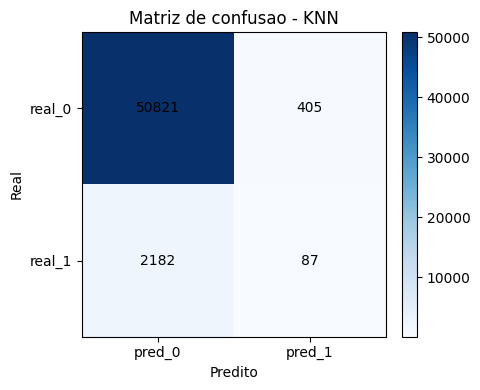

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(matriz_confusao_knn.values, cmap='Blues')
ax.set_xticks(range(2), matriz_confusao_knn.columns)
ax.set_yticks(range(2), matriz_confusao_knn.index)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusao - KNN')

for i in range(2):
    for j in range(2):
        ax.text(j, i, matriz_confusao_knn.iloc[i, j], ha='center', va='center')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


#### Item 6 - Conclusao da avaliacao KNN

A conclusao abaixo compara os cenarios de idade e escala, sintetiza o tuning com GridSearchCV e as principais metricas do KNN tunado e interpreta o resultado considerando o desbalanceamento da target. Esta etapa nao exporta arquivos; os resultados permanecem documentados no notebook.


In [11]:
melhor_cenario = comparacao_cenarios_knn.iloc[0]
segundo_cenario = comparacao_cenarios_knn.iloc[1]

conclusao_knn = pd.DataFrame([
    {
        'aspecto': 'melhor_cenario_validacao',
        'conclusao': f"idade={melhor_cenario['idade']}, escala={melhor_cenario['escala']}, k={melhor_cenario['n_neighbors']}, weights={melhor_cenario['weights']}",
    },
    {
        'aspecto': 'comparacao_idade_escala',
        'conclusao': f"Melhor F1 de validacao={melhor_cenario['f1']} contra {segundo_cenario['f1']} do segundo melhor cenario ({segundo_cenario['idade']} + {segundo_cenario['escala']}).",
    },
    {
        'aspecto': 'tuning_gridsearch',
        'conclusao': f"Melhor F1 medio no CV={metricas_teste_knn['melhor_f1_cv']} com parametros {metricas_teste_knn['melhores_parametros']}",
    },
    {
        'aspecto': 'base_utilizada',
        'conclusao': f"{metricas_teste_knn['linhas_treino_usadas']} registros de treino e {metricas_teste_knn['linhas_teste_avaliadas']} registros de teste",
    },
    {
        'aspecto': 'desempenho_teste',
        'conclusao': f"accuracy={metricas_teste_knn['accuracy']}, balanced_accuracy={metricas_teste_knn['balanced_accuracy']}, roc_auc={metricas_teste_knn['roc_auc']}",
    },
    {
        'aspecto': 'classe_positiva',
        'conclusao': f"precision={metricas_teste_knn['precision']}, recall={metricas_teste_knn['recall']} e f1={metricas_teste_knn['f1']}",
    },
    {
        'aspecto': 'interpretacao',
        'conclusao': 'A accuracy alta e influenciada pelo forte desbalanceamento da target; recall e F1 baixos indicam baixa capacidade de recuperar casos positivos.',
    },
    {
        'aspecto': 'decisao',
        'conclusao': 'O KNN deve ser tratado como baseline inicial, nao como modelo final para o problema.',
    },
    {
        'aspecto': 'proximos_passos',
        'conclusao': 'Comparar com modelos mais adequados a dados tabulares desbalanceados, como regressao logistica balanceada, arvores, random forest, gradient boosting ou modelos com ajuste de threshold.',
    },
])

class TabelaHTML(str):
    def _repr_html_(self):
        return str(self)

estilo_tabela_conclusao = '''
<style>
.tabela-conclusao-knn {
    width: 100%;
    table-layout: fixed;
    border-collapse: collapse;
}
.tabela-conclusao-knn th,
.tabela-conclusao-knn td {
    text-align: left;
    vertical-align: top;
    white-space: normal;
    word-wrap: break-word;
    overflow-wrap: anywhere;
    font-size: 13px;
    line-height: 1.35;
    padding: 8px 10px;
}
.tabela-conclusao-knn th:first-child,
.tabela-conclusao-knn td:first-child {
    width: 22%;
    font-weight: 600;
}
.tabela-conclusao-knn th:nth-child(2),
.tabela-conclusao-knn td:nth-child(2) {
    width: 78%;
}
</style>
'''

tabela_conclusao_knn_html = conclusao_knn.to_html(
    index=False,
    escape=True,
    classes='tabela-conclusao-knn',
)

TabelaHTML(estilo_tabela_conclusao + tabela_conclusao_knn_html)


aspecto,conclusao
melhor_cenario_validacao,"idade=cap, escala=padronizacao, k=5, weights=distance"
comparacao_idade_escala,Melhor F1 de validacao=0.0721 contra 0.072 do segundo melhor cenario (num + padronizacao).
tuning_gridsearch,"Melhor F1 medio no CV=0.0694 com parametros {'knn__metric': 'minkowski', 'knn__n_neighbors': 3, 'knn__weights': 'distance', 'preprocessamento__numericas__scaler': StandardScaler()}"
base_utilizada,171182 registros de treino e 53495 registros de teste
desempenho_teste,"accuracy=0.9516, balanced_accuracy=0.5152, roc_auc=0.5493"
classe_positiva,"precision=0.1768, recall=0.0383 e f1=0.063"
interpretacao,A accuracy alta e influenciada pelo forte desbalanceamento da target; recall e F1 baixos indicam baixa capacidade de recuperar casos positivos.
decisao,"O KNN deve ser tratado como baseline inicial, nao como modelo final para o problema."
proximos_passos,"Comparar com modelos mais adequados a dados tabulares desbalanceados, como regressao logistica balanceada, arvores, random forest, gradient boosting ou modelos com ajuste de threshold."


---

## Resultado da Parte 3

Este notebook treina e avalia um baseline KNN usando as bases encoded finais da Parte 2:

```text
bases/treino/x_encoded.parquet
bases/treino/y.parquet
bases/teste/x_encoded.parquet
bases/teste/y.parquet
```

Como KNN depende de distancia, a Parte 3 compara `CO_IDADE_PACIENTE_CAP` e `CO_IDADE_PACIENTE_NUM`, cada uma com padronizacao e normalizacao. A coluna numerica de idade do cenario e as variaveis numericas de contexto sao escaladas; as dummies categoricas permanecem como `0/1`.

A avaliacao compara os cenarios por F1 e balanced accuracy na validacao, refina o melhor cenario com GridSearchCV e depois avalia o estimador tunado no conjunto completo de teste. Em geral, o KNN apresenta accuracy alta, mas balanced accuracy, recall e F1 baixos para a classe positiva. Isso mostra que o modelo acompanha majoritariamente a classe negativa e tem baixa recuperacao de casos provaveis de cancer de mama.

Conclusao: o KNN fica registrado como baseline inicial, e a comparacao entre idade cap/num, padronizacao/normalizacao e tuning com GridSearchCV ajuda a documentar a sensibilidade do modelo a escolhas de escala e hiperparametros. Ainda assim, ele nao deve ser usado como modelo final sem comparacao com algoritmos mais adequados a bases tabulares grandes e desbalanceadas.
